In [27]:
# Import wikipediaapi to access and retrieve information from Wikipedia pages.
import wikipediaapi

# Import NLTK (Natural Language Toolkit), which provides tools for working with and processing language text.
import nltk

# Import ssl to handle secure HTTPS connections.
# This is useful when downloading NLTK resources over the internet.
import ssl

# Import re (Regular Expressions) for finding and manipulating specific patterns in text.
import re

# Import NumPy for working with numerical data and arrays.
import numpy as np

# Import the English stopwords list from NLTK.
# Stopwords are common words such as "the", "is", "and", and "of" that are often removed during text preprocessing.
from nltk.corpus import stopwords

# Import WordNetLemmatizer to convert words into their base/dictionary form.
# For example, "running" can be changed to "run".
from nltk.stem import WordNetLemmatizer

# Import TfidfVectorizer to convert text into numerical TF-IDF features.
# These numerical features can later be used by machine learning algorithms.
from sklearn.feature_extraction.text import TfidfVectorizer

# Import KMeans, an unsupervised machine learning algorithm used to group similar text documents into clusters.
from sklearn.cluster import KMeans

# Import silhouette_score to measure how well the data has been grouped into clusters. (To decide the best K value)
from sklearn.metrics import silhouette_score

# Import Matplotlib for creating charts and visualizations.
import matplotlib.pyplot as plt

In [28]:
# ---------------------------------------------------------
# Configure SSL
# ---------------------------------------------------------

# Some systems may have problems establishing a secure HTTPS connection when downloading NLTK data.
# The following code creates an unverified HTTPS context if Python provides the required SSL functionality.
try:
    _create_unverified_https_context = ssl._create_unverified_context
# If the required SSL functionality is not available, simply skip this step and continue with the program.
except ArithmeticError:
    pass
# If the SSL function is available, use it as the default HTTPS context for secure connections.
else:
    ssl._create_default_https_context = _create_unverified_https_context

In [29]:
# ---------------------------------------------------------
# Download Required NLTK Resources
# ---------------------------------------------------------

# Download the list of English stopwords from NLTK.
# This is required when we want to remove common words that do not add much meaning to the text.
nltk.download("stopwords")

# Download the WordNet dictionary.
# WordNet is required by WordNetLemmatizer for converting words into their base forms.
# Eg: "run" for running and "play" for played.
nltk.download("wordnet")

# Download additional WordNet language data required by some NLTK functions.
nltk.download("omw-1.4")

print("NLTK data downloaded successfully using the manual method")
print("Libraries imported and NLTK data downloaded successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...


NLTK data downloaded successfully using the manual method
Libraries imported and NLTK data downloaded successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!


In [30]:
# ---------------------------------------------------------
# Fetch Wikipedia Articles
# ---------------------------------------------------------

# Store the titles of the Wikipedia articles that will be used for clustering. 
# The articles cover three different subject areas:
# Astronomy, Biology, and Computer Science.
# Astronomy => ["Galaxy", "Black hole", "Supernova"]
# Biology => ["DNA", "Photosynthesis", "Evolution"]
# Computer Science => ["Machine learning", "Artificial intelligence", "Computer programming"]
article_titles = [
    "Galaxy", "Black hole", "Machine learning",
    "DNA", "Photosynthesis", "Computer programming", 
    "Evolution", "Supernova", "Artificial intelligence"
]

# Create a Wikipedia API client.
# "en" specifies that we want to retrieve articles from English Wikipedia.
# The user-agent identifies the application when making requests to Wikipedia.
wiki_api = wikipediaapi.Wikipedia("My-Clustering-Project/1.0.0", "en")

# Create an empty list to store the text content of the articles that are successfully retrieved from Wikipedia.
documents = []

# Go through each article title in the list and retrieve its Wikipedia page.
for title in article_titles:
    # Request the Wikipedia page corresponding to the current article title.
    page = wiki_api.page(title)
    # Check whether the requested Wikipedia page actually exists.
    if page.exists():
        # Add the complete text of the article to the documents list.
        # Each item in this list will later be treated as one document for text preprocessing and clustering.
        documents.append(page.text)
        # Display a message so we know which articles were retrieved successfully.
        print(f"Successfully fetched: {title}")
    else:
        # Display a warning if Wikipedia does not contain a page with the requested title.
        print(f"Could not find page: {title}")

Successfully fetched: Galaxy
Successfully fetched: Black hole
Successfully fetched: Machine learning
Successfully fetched: DNA
Successfully fetched: Photosynthesis
Successfully fetched: Computer programming
Successfully fetched: Evolution
Successfully fetched: Supernova
Successfully fetched: Artificial intelligence


In [31]:
# ---------------------------------------------------------
# Data Pre-processing (Pre-process the Text)
# ---------------------------------------------------------

# Load the built-in English stopword list provided by NLTK to a python set.
# Stopwords are common words such as "the", "is", "and", and "of" that usually do not provide much useful information for clustering.
stop_words = set(stopwords.words("english"))
# Display the stopwords so we can see which common words will be removed during preprocessing.
print(f"Stop words:\n {stop_words}")
# Display the total number of stopwords in the English stopword list.
print(f"Number of stop words: {len(stop_words)}")

# Create a WordNet lemmatizer.
# The lemmatizer converts words into their base or dictionary form.
# For example, "running" can be changed to "run".
lemmatizer = WordNetLemmatizer()

# Define a function to clean and prepare one document for further text analysis and machine learning.
def preprocess_text(text):
    # Convert all characters to lowercase so that words such as "Computer" and "computer" are treated as the same word.
    text = text.lower()

    # Remove punctuation, numbers, and other characters that are not lowercase English letters or spaces.
    # This leaves only the words that will be used for text analysis.
    text = re.sub(r"[^a-z\s]", "", text)

    # Split the cleaned text into individual words (tokens).
    # For example, "machine learning is useful" becomes: ["machine", "learning", "is", "useful"]
    words = text.split()

    # Remove stopwords and lemmatize the remaining words.
    # "pos='v'" tells the lemmatizer to treat the words as verbs, when determining their base form.
    processed_words = [
        lemmatizer.lemmatize(word, pos="v")
        for word in words
        if word not in stop_words
    ]

    # Join the processed words back together into a single string.
    # This format is required because the TF-IDF vectorizer will process each document as a text string.
    return " ".join(processed_words)

# Apply the preprocessing function to every Wikipedia article (6 articles) collected earlier.
# The result is a new list containing the cleaned version of each document.
processed_documents = [preprocess_text(doc) for doc in documents]

print("Text preprocessing complete")
# Display the first 500 characters of the first document before preprocessing.
# This allows us to compare the original Wikipedia text with the cleaned text.
print(f"\nDocument 1 Before preprocessing:\n{documents[0][:500]}")
# Display the first 500 characters of the same document after preprocessing.
# This helps us see the effect of lowercasing, cleaning, stopword removal, and lemmatization.
print(f"\nDocument 1 After preprocessing:\n{processed_documents[0][:500]}")

Stop words:
 {'over', 'here', 'hers', 'weren', "i'm", 'through', 'it', 'our', 'off', 'him', 'not', 'from', "you've", 'these', "i'd", "we've", 'as', 'her', 'nor', 'above', 'a', 'during', "you'll", 'but', "they've", 'won', "should've", 'myself', "she'd", "she's", 'down', "they'll", 'needn', 'doing', 'itself', 'until', 'aren', "it's", 'into', 'ain', "mustn't", 'himself', 'my', 'further', 'their', 'will', 'with', 'than', 'they', 'other', 'yourselves', 'its', 'hasn', 'most', 'in', 'does', 'each', 'then', "he'd", 'by', 'she', "shan't", 'because', "doesn't", "isn't", "couldn't", "weren't", "don't", 'own', 'is', 'both', 'don', 'there', 'against', 'shouldn', 'why', "wouldn't", 'do', "hasn't", 'being', 'under', 'very', "won't", 'had', 'so', "we'd", 'just', 'o', 'to', "she'll", 'was', "i've", 'me', 'between', 'll', 'yours', 'ourselves', 'same', 'i', "mightn't", 'herself', 'should', 'some', 'you', 'he', "it'll", 'again', "wasn't", 'after', 'and', 've', 'm', "didn't", 'been', 'his', 'isn', 'wouldn'

In [32]:
# ---------------------------------------------------------
# Convert Text to Numerical Vectors using TF-IDF
# ---------------------------------------------------------

# Create a TF-IDF vectorizer.
# TF-IDF (Term Frequency-Inverse Document Frequency) converts text documents into numerical values that a machine learning algorithm (K-means) can understand.
# max_features=1000 means that only the 1,000 most important words (features) will be kept in the final representation.
vectorizer = TfidfVectorizer(max_features=1000)

# Learn the important words from all the processed documents and convert each document into a numerical TF-IDF vector.
# The resulting matrix contains:
# - One row for each document
# - One column for each selected word/feature
# - A TF-IDF value showing the importance of a word in a document
tfidf_matrix = vectorizer.fit_transform(processed_documents)

# Display the TF-IDF matrix.
# The matrix is usually stored as a sparse matrix because most documents contain only a small number of the possible words.
print(tfidf_matrix)

# Confirm that the TF-IDF conversion has been completed successfully.
print("TF-IDF matrix created successfully")
# Display the dimensions of the TF-IDF matrix.
# The first value represents the number of documents, while the second value represents the number of selected words/features.
print(f"Shape of the matrix: {tfidf_matrix.shape}")

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5237 stored elements and shape (9, 1000)>
  Coords	Values
  (0, 368)	0.3973655031599893
  (0, 670)	0.004093027689339178
  (0, 901)	0.011108668071710485
  (0, 863)	0.36898225293427583
  (0, 902)	0.005554334035855243
  (0, 869)	0.03193115650392772
  (0, 768)	0.006269536675130964
  (0, 615)	0.032653511872413915
  (0, 461)	0.0344824517132203
  (0, 372)	0.08037787537824964
  (0, 263)	0.037617220050785785
  (0, 207)	0.050156293401047713
  (0, 538)	0.045291652385342454
  (0, 98)	0.010047234422281205
  (0, 928)	0.01507085163342181
  (0, 393)	0.021287437669285144
  (0, 990)	0.007535425816710905
  (0, 225)	0.0025118086055703013
  (0, 541)	0.004529165238534245
  (0, 560)	0.17384740763249534
  (0, 755)	0.0037028893572368282
  (0, 979)	0.08595358147612273
  (0, 185)	0.024068780822039382
  (0, 842)	0.018808610025392893
  (0, 367)	0.6634584740260536
  :	:
  (8, 626)	0.012876333379587495
  (8, 900)	0.002063494428182088
  (8, 742)	0.00372078

In [33]:
# ---------------------------------------------------------
# Apply K-Means++ Clustering Machine Learning Algorithm
# ---------------------------------------------------------

# Specify the number of clusters we want K-Means to create.
# In this project, the articles cover three main subject areas: Astronomy, Biology, and Computer Science.
# Therefore, we start by asking K-Means to create 3 clusters.
k = 3

# Create the K-Means clustering model.
#
# n_clusters=k:
#     Specifies the number of clusters to create.
#
# random_state=42:
#     Ensures that the same initial conditions are used each time the code is run, making the results more reproducible.
#
# n_init=10:
#     Runs the K-Means algorithm 10 times with different initial random centroid positions and keeps the best result.
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Train the K-Means model using the TF-IDF sparse matrix.
# Each row represents a document, and the TF-IDF values represent the numerical features used by K-Means to measure similarity between documents.
kmeans.fit(tfidf_matrix)

# Get the cluster assigned to each document.
# Each document receives a cluster label such as 0, 1, or 2.
# Documents assigned to the same cluster are considered similar according to their TF-IDF features.
labels = kmeans.labels_

# Display the cluster label assigned to each document.
print(labels)

[2 2 1 0 0 1 0 2 1]


In [34]:
# ---------------------------------------------------------
# Evaluate the Clustering Results
# ---------------------------------------------------------

# K-Means automatically calculates the Within-Cluster Sum of Squares (WCSS), also called "inertia", when the model is fitted for k=3.
# WCSS measures how close the documents in each cluster are to their cluster centroid. 
# A lower WCSS generally means that the documents are more closely grouped around their cluster centroids.
wcss = kmeans.inertia_

# Calculate the Silhouette Score to evaluate how well the clusters are separated from one another.
# The score considers both:
# 1. How similar each document is to other documents in its own cluster.
# 2. How different each document is from documents in other clusters.
#
# The Silhouette Score ranges from -1 to 1:
# - A value close to 1 indicates well-separated clusters.
# - A value close to 0 indicates overlapping clusters.
# - A negative value may indicate that some documents are assigned to an inappropriate cluster.
sil_score = silhouette_score(tfidf_matrix, kmeans.labels_)

# Display the clustering evaluation results.
print("Model Evaluation Metrics")
# Display WCSS with four decimal places.
print(f"WCSS (Inertia): {wcss:.4f}")
# Display the Silhouette Score with four decimal places.
print(f"Silhouette Score: {sil_score:.4f}")

Model Evaluation Metrics
WCSS (Inertia): 4.4569
Silhouette Score: 0.1080


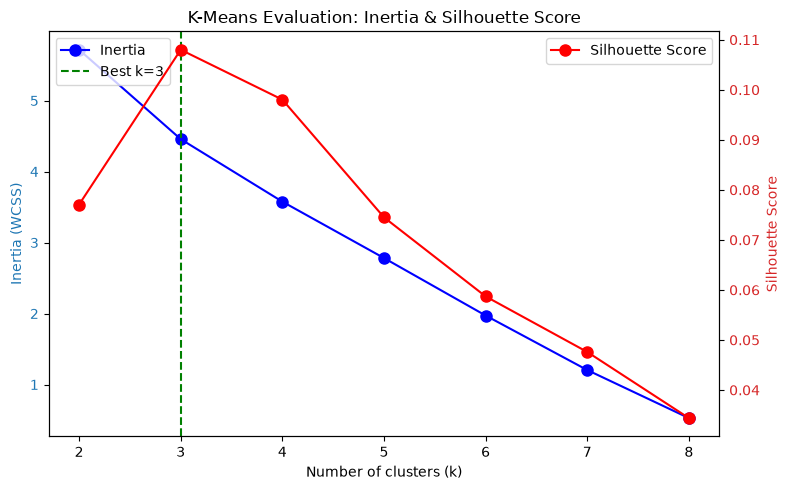

Suggested optimal number of clusters by silhouette score: k = 3


In [35]:
# ---------------------------------------------------------
# Find the Optimal Number of Clusters (Optimum K Value)
# ---------------------------------------------------------

# K-Means algorithm requires us to specify the number of clusters (k) before training the model.
# Since we do not always know the best value of k in advance,
# we test several different values and evaluate the quality of the resulting clusters.

# We use two evaluation metrics:
#
# 1. Inertia (WCSS):
#    Measures how close documents are to the centroid of
#    their assigned cluster. Lower values indicate more
#    compact clusters.
#
# 2. Silhouette Score:
#    Measures how well each document fits within its own
#    cluster compared with other clusters. Higher values
#    generally indicate better-separated clusters.
#
# Using both metrics gives us a better basis for selecting k.

# Get the total number of documents in the TF-IDF matrix.
# The number of rows represents the number of documents, which is 9.
num_docs = tfidf_matrix.shape[0]

# ---------------------------------------------------------
# Define the range of k values to test
# ---------------------------------------------------------

# Test different numbers of clusters, starting from 2.
# We start with k=2 because calculating a Silhouette Score requires at least two clusters.
# range(2, num_docs) generates values from 2 up to num_docs - 1.
# For this example, there are 9 documents: 2, 3, 4, 5, 6, 7, 8
k_values = range(2, num_docs)

# Create empty lists to store the evaluation results for each value of k.
inertia_values = []
silhouette_values = []

# ---------------------------------------------------------
# Train K-Means for each value of k
# ---------------------------------------------------------

# Repeat the K-Means process for every k value we want to test.
for k in k_values:
    # Create a K-Means model using the current value of k.
    # random_state=42 ensures that the results are reproducible when the code is run again.
    # n_init=10 means K-Means will try 10 different initial centroid positions and select the best result.
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Train the K-Means model and return the cluster label assigned to each document.
    labels = kmeans.fit_predict(tfidf_matrix)

    # Store the WCSS (inertia) calculated by K-Means.
    # This allows us to compare the compactness of the clusters for different values of k.
    inertia_values.append(kmeans.inertia_)

    # Calculate the Silhouette Score for the current clustering result and store it for later comparison.
    sil_score = silhouette_score(tfidf_matrix, labels)
    silhouette_values.append(sil_score)

# ---------------------------------------------------------
# Plot the evaluation results
# ---------------------------------------------------------

# Create the main plot and the first y-axis.
# We use one x-axis for k and two y-axes because the Inertia and Silhouette Score have different scales.
fig, ax1 = plt.subplots(figsize=(8, 5))

# Set the label for the x-axis.
ax1.set_xlabel("Number of clusters (k)")

# Set the label for the first y-axis.
ax1.set_ylabel("Inertia (WCSS)", color="tab:blue")

# Plot the Inertia values for each k.
# The line helps us observe how WCSS changes as the number of clusters increases.
ax1.plot(
    k_values,
    inertia_values,
    "bo-",
    markersize=8,
    label="Inertia"
)

# Set the colour of the first y-axis tick labels.
ax1.tick_params(axis="y", labelcolor="tab:blue")
# Add a title describing what the graph shows.
ax1.set_title("K-Means Evaluation: Inertia & Silhouette Score")

# ---------------------------------------------------------
# Create a second y-axis for Silhouette Score
# ---------------------------------------------------------

# Create a second y-axis that shares the same x-axis.
# This allows us to display the Silhouette Score alongside the Inertia values.
ax2 = ax1.twinx()

# Set the label for the second y-axis.
ax2.set_ylabel("Silhouette Score", color="tab:red")

# Plot the Silhouette Score for each value of k.
ax2.plot(
    k_values,
    silhouette_values,
    "ro-",
    markersize=8,
    label="Silhouette Score"
)

# Set the colour of the second y-axis tick labels.
ax2.tick_params(axis="y", labelcolor="tab:red")

# ---------------------------------------------------------
# Identify and mark the best k using Silhouette Score
# ---------------------------------------------------------

# Find the position of the highest Silhouette Score.
# A higher Silhouette Score generally indicates that the clusters are better separated.
best_k_index = silhouette_values.index(max(silhouette_values))

# Use that position to find the corresponding value of k.
best_k = k_values[best_k_index]

# Draw a vertical dashed line on the graph to highlight the k value with the highest Silhouette Score.
ax1.axvline(
    x=best_k,
    color="green",
    linestyle="--",
    label=f"Best k={best_k}"
)

# ---------------------------------------------------------
# Add legends and display the graph
# ---------------------------------------------------------

# Adjust the layout so that the labels and title fit neatly within the figure.
fig.tight_layout()

# Display the Inertia legend.
ax1.legend(loc="upper left")

# Display the Silhouette Score legend.
ax2.legend(loc="upper right")

# Show the completed graph.
plt.show()

# Display the value of k that produced the highest Silhouette Score.
print(
    f"Suggested optimal number of clusters by "
    f"silhouette score: k = {best_k}"
)

In [36]:
# ---------------------------------------------------------
# Use the Trained Model to Predict a New Document
# ---------------------------------------------------------

# Now that the K-Means model has been trained, we can use it
# to assign a cluster to a new document that was not part of
# the original training documents.
#
# The new document will go through the same preprocessing
# and TF-IDF transformation steps used for the original data.
# This ensures that the new document is represented in the
# same way as the documents used to train the model.

# ---------------------------------------------------------
# Step 1: Define a new, unseen document
# ---------------------------------------------------------

# Create a new document about algorithms and data structures.
# This document was not included in the original Wikipedia articles.
new_text = (
    "An algorithm is a set of well-defined instructions designed "
    "to perform a specific task or solve a computational problem. "
    "In computer science, the study of algorithms is fundamental "
    "to creating efficient and scalable software. Data structures, "
    "such as arrays and hash tables, are used to organize data in "
    "a way that allows these algorithms to access and manipulate "
    "it effectively."
)

# ---------------------------------------------------------
# Step 2: Apply the same text pre-processing
# ---------------------------------------------------------

# Apply the same preprocessing function that was used
# for the original Wikipedia documents.
#
# It is important to use the same preprocessing steps so that
# the new document has the same format as the documents
# used to train the model.
processed_new_text = preprocess_text(new_text)

# Display the cleaned version of the new document so that
# we can see how the preprocessing has changed the text.
print(f"Cleaned Text: {processed_new_text}")

# ---------------------------------------------------------
# Step 3: Convert the new document into a TF-IDF vector
# ---------------------------------------------------------

# Use the TF-IDF vectorizer that was already fitted
# using the original documents.
#
# IMPORTANT:
# Use transform() rather than fit_transform().
#
# transform() uses the vocabulary and TF-IDF information
# already learned from the original documents.
#
# We must NOT fit the vectorizer again because that would
# create a different vocabulary and representation from
# the one used to train the K-Means model.
new_tfidf_vector = vectorizer.transform([processed_new_text])

# Display the shape of the new TF-IDF vector.
# It should have one row because we are predicting one document,
# and the same number of columns as the original TF-IDF matrix.
print(f"\nShape of the new vector: {new_tfidf_vector.shape}")

# ---------------------------------------------------------
# Step 4: Predict the cluster for the new document
# ---------------------------------------------------------

# Use the trained K-Means model to determine which cluster
# is most suitable for the new document.
#
# K-Means compares the new document's TF-IDF representation
# with the learned cluster centroids and assigns it to
# the nearest cluster.
predicted_label = kmeans.predict(new_tfidf_vector)

# Display the cluster assigned to the new document.
# predicted_label[0] is used because the prediction is returned
# as an array, even though we are predicting only one document.
print(f"\nThe new document belongs to cluster: {predicted_label[0]}")

Cleaned Text: algorithm set welldefined instructions design perform specific task solve computational problem computer science study algorithms fundamental create efficient scalable software data structure array hash table use organize data way allow algorithms access manipulate effectively

Shape of the new vector: (1, 1000)

The new document belongs to cluster: 1
